In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

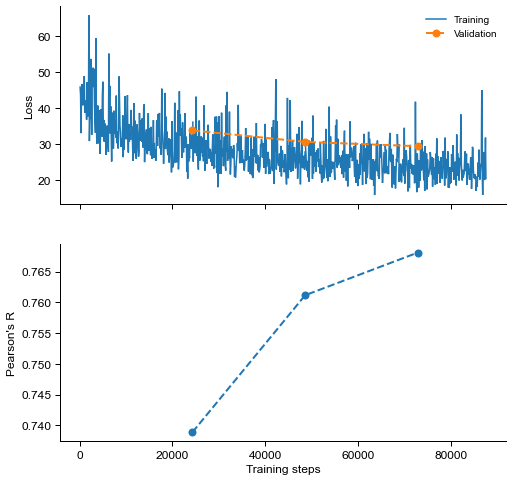

In [5]:
metrics = pd.read_csv(
    "models/data_JUL28_3_a100/logs/lightning_logs/version_0/metrics.csv"
)

i = metrics.loss.abs() > 100
metrics.loc[i, "loss"] = pd.NA

val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]

fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(metrics.step, metrics.loss, label="Training")
ax[0].plot(
    val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation"
)
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Validation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")

fig.set_size_inches(8, 8)

In [6]:
val_metrics

,epoch,loss,step,val_loss,val_pcc
243,0,NaN,24308,33.799473,0.738878
487,0,NaN,48617,30.585577,0.761160
731,0,NaN,72926,29.380619,0.768102
